In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from darts import TimeSeries
from darts.models import RandomForestModel
from darts.metrics import mape, mae, mse
from darts.utils.model_selection import train_test_split
from darts.dataprocessing.transformers import Scaler, Diff
from darts.utils.missing_values import fill_missing_values
import warnings
import traceback

warnings.filterwarnings("ignore")

URLS = {
    "ihsg": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/ihsg.csv",
    "bi_rate": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/bi_interest_rate.csv",
    "cpi": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/cpi.csv",
    "m2": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/m2.csv",
    "npl_ratio": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/npl_ratio.csv",
    "npl": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/npl.csv",
    "usdidr": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/usd_idr.csv",
    "coal": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Coal.csv",
    "copper": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Copper.csv",
    "nickel": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Nickel.csv",
    "silver": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Silver.csv",
    "tin": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Tin.csv",
    "sti": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/STI.csv",
    "gold": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Gold.csv",
}

COVARIATE_SETS = {
    # Baseline
    "None": [],

    # Per kategori
    "Macro": ["BI_Rate", "CPI", "M2", "NPL_Ratio", "USDIDR"],
    "Commodity": ["Coal", "Copper", "Nickel", "Silver", "Tin", "Gold"],
    "Regional": ["STI"],

    # Kombinasi
    "Macro_Regional": ["BI_Rate", "CPI", "M2", "NPL_Ratio", "USDIDR", "STI"],
    "Commodity_Regional": ["Coal", "Copper", "Nickel", "Silver", "Tin", "Gold", "STI"],
    "Full": ["BI_Rate", "CPI", "M2", "NPL_Ratio", "USDIDR", "Coal", "Copper", "Nickel", "Silver", "Tin", "STI", "Gold"],
}

LEVEL_VARS = ["M2", "USDIDR", "Coal", "Copper", "Nickel", "Silver", "Tin", "STI", "Gold"]
RATE_VARS = ["BI_Rate", "CPI", "NPL_Ratio"]

SCENARIOS = {
    "W30_H1": {"window": 30, "horizon": 1},
    "W60_H1": {"window": 60, "horizon": 1},
    "W120_H1": {"window": 120, "horizon": 1},
}

RF_CONFIG = {
    "n_estimators": 100,
    "max_depth": 5,
    "max_samples": 0.7,
    "max_features": None,
    "n_jobs": -1,
    "random_state": 42,
}

DATE_START = "2015-01-01"
DATE_END = "2025-01-31"

print(f"Covariate sets: {len(COVARIATE_SETS)}")
for k, v in COVARIATE_SETS.items():
    print(f"  {k:20s} -> {len(v)} vars: {v}")

Covariate sets: 7
  None                 -> 0 vars: []
  Macro                -> 5 vars: ['BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR']
  Commodity            -> 6 vars: ['Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold']
  Regional             -> 1 vars: ['STI']
  Macro_Regional       -> 6 vars: ['BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'STI']
  Commodity_Regional   -> 7 vars: ['Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold', 'STI']
  Full                 -> 12 vars: ['BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'STI', 'Gold']


In [4]:
# IHSG
df_ihsg = pd.read_csv(URLS["ihsg"])
df_ihsg.columns = ["date", "IHSG"]
df_ihsg["date"] = pd.to_datetime(df_ihsg["date"], format="%d/%m/%Y")
df_ihsg = df_ihsg.sort_values("date").reset_index(drop=True)
print(f"IHSG: {len(df_ihsg)} rows | {df_ihsg['date'].min().date()} to {df_ihsg['date'].max().date()}")
df_ihsg.head()

IHSG: 2660 rows | 2015-01-02 to 2025-12-30


,date,IHSG
0,2015-01-02,5242.769
1,2015-01-05,5219.995
2,2015-01-06,5169.060
3,2015-01-07,5207.118
4,2015-01-08,5211.828


In [5]:
# Macro variables

# BI Rate - dd/mm/yy, values have %
df_bi = pd.read_csv(URLS["bi_rate"])
df_bi.columns = ["date", "BI_Rate"]
df_bi["date"] = pd.to_datetime(df_bi["date"], format="%d/%m/%y")
df_bi["BI_Rate"] = df_bi["BI_Rate"].str.replace("%", "").astype(float)
df_bi = df_bi.sort_values("date").reset_index(drop=True)
print(f"BI Rate: {len(df_bi)} rows")

# CPI - yyyy-mm-dd
df_cpi = pd.read_csv(URLS["cpi"])
df_cpi.columns = ["date", "CPI"]
df_cpi["date"] = pd.to_datetime(df_cpi["date"], format="%Y-%m-%d")
df_cpi = df_cpi.sort_values("date").reset_index(drop=True)
print(f"CPI: {len(df_cpi)} rows")

# M2 - mm/dd/yyyy, comma thousands
df_m2 = pd.read_csv(URLS["m2"])
df_m2.columns = ["date", "M2"]
df_m2["date"] = pd.to_datetime(df_m2["date"], format="%m/%d/%Y")
df_m2["M2"] = df_m2["M2"].str.replace('"', '').str.replace(",", "").astype(float)
df_m2 = df_m2.sort_values("date").reset_index(drop=True)
print(f"M2: {len(df_m2)} rows")

# NPL Ratio - dd/mm/yy, values have %
df_npl = pd.read_csv(URLS["npl_ratio"])
df_npl.columns = ["date", "NPL_Ratio"]
df_npl["date"] = pd.to_datetime(df_npl["date"], format="%d/%m/%y")
df_npl["NPL_Ratio"] = df_npl["NPL_Ratio"].str.replace("%", "").astype(float)
df_npl = df_npl.sort_values("date").reset_index(drop=True)
print(f"NPL Ratio: {len(df_npl)} rows")

# USD/IDR (Daily) - dd/mm/yyyy, European number format
df_usd = pd.read_csv(URLS["usdidr"])
df_usd.columns = ["date", "USDIDR"]
df_usd["date"] = pd.to_datetime(df_usd["date"], format="%d/%m/%Y")
df_usd["USDIDR"] = (
    df_usd["USDIDR"].astype(str)
    .str.replace('"', '').str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False).astype(float)
)
df_usd = df_usd.sort_values("date").reset_index(drop=True)
print(f"USD/IDR: {len(df_usd)} rows")

BI Rate: 121 rows
CPI: 697 rows
M2: 121 rows
NPL Ratio: 121 rows
USD/IDR: 2854 rows


In [6]:
df_npl

,date,NPL_Ratio
0,2015-01-01,2.37
1,2015-02-01,2.43
2,2015-03-01,2.40
3,2015-04-01,2.48
4,2015-05-01,2.58
...,...,...
116,2024-09-01,2.21
117,2024-10-01,2.20
118,2024-11-01,2.19
119,2024-12-01,2.08


In [7]:
# Commodities + sti

def load_daily_csv(url, col_name, date_formats=None):
    """Load a daily CSV with flexible date parsing."""
    df = pd.read_csv(url)
    df.columns = ["date", col_name]
    
    # Try multiple date formats
    if date_formats is None:
        date_formats = ["%d/%m/%Y", "%m/%d/%Y", "%Y-%m-%d", "%d/%m/%y"]
    
    parsed = False
    for fmt in date_formats:
        try:
            df["date"] = pd.to_datetime(df["date"], format=fmt)
            parsed = True
            break
        except (ValueError, TypeError):
            continue
    
    if not parsed:
        # Fallback: let pandas infer
        df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    
    # Clean numeric values (handle European format, commas, etc.)
    if df[col_name].dtype == object:
        df[col_name] = (
            df[col_name].astype(str)
            .str.replace('"', '', regex=False)
            .str.replace(',', '', regex=False)
            .astype(float)
        )
    else:
        df[col_name] = df[col_name].astype(float)
    
    df = df.sort_values("date").reset_index(drop=True)
    return df


# Load all commodity + STI data
daily_vars = {
    "Coal": URLS["coal"],
    "Copper": URLS["copper"],
    "Nickel": URLS["nickel"],
    "Silver": URLS["silver"],
    "Tin": URLS["tin"],
    "Gold": URLS["gold"],
    "STI": URLS["sti"],
}

daily_dfs = {}
for var_name, url in daily_vars.items():
    try:
        df_temp = load_daily_csv(url, var_name)
        daily_dfs[var_name] = df_temp
        print(f"{var_name:8s}: {len(df_temp)} rows | {df_temp['date'].min().date()} to {df_temp['date'].max().date()}")
    except Exception as e:
        print(f"{var_name:8s}: ERROR - {e}")

Coal    : 2839 rows | 2015-01-02 to 2025-12-31
Copper  : 2780 rows | 2015-01-02 to 2025-12-31
Nickel  : 2774 rows | 2015-01-02 to 2025-12-31
Silver  : 2857 rows | 2015-01-01 to 2025-12-31
Tin     : 2780 rows | 2015-01-02 to 2025-12-31
Gold    : 2857 rows | 2015-01-01 to 2025-12-31
STI     : 2766 rows | 2015-01-02 to 2025-12-31


In [8]:
# ============================================================
# MERGE: Start from IHSG daily as base
# ============================================================

df_merged = df_ihsg.copy()
df_merged = df_merged[
    (df_merged["date"] >= DATE_START) & (df_merged["date"] <= DATE_END)
].reset_index(drop=True)
print(f"Base IHSG: {len(df_merged)} rows")

# --- Monthly variables: forward-fill via merge_asof ---
monthly_dfs = {
    "BI_Rate": df_bi, "CPI": df_cpi, "M2": df_m2, "NPL_Ratio": df_npl,
}
for var_name, df_monthly in monthly_dfs.items():
    df_merged = pd.merge_asof(
        df_merged.sort_values("date"),
        df_monthly[["date", var_name]].sort_values("date"),
        on="date", direction="backward"
    )
    print(f"  Merged {var_name} (monthly->daily): {df_merged[var_name].notna().sum()} non-null")

# --- Daily variables: left merge + forward fill ---
# USD/IDR
df_merged = pd.merge(df_merged, df_usd[["date", "USDIDR"]], on="date", how="left")
df_merged["USDIDR"] = df_merged["USDIDR"].ffill()
print(f"  Merged USDIDR (daily): {df_merged['USDIDR'].notna().sum()} non-null")

# Commodities + STI
for var_name, df_daily in daily_dfs.items():
    df_merged = pd.merge(df_merged, df_daily[["date", var_name]], on="date", how="left")
    df_merged[var_name] = df_merged[var_name].ffill()
    non_null = df_merged[var_name].notna().sum()
    null_count = df_merged[var_name].isna().sum()
    print(f"  Merged {var_name:8s} (daily): {non_null} non-null, {null_count} missing")

# Drop rows with any NaN
before_drop = len(df_merged)
df_merged = df_merged.dropna().reset_index(drop=True)
print(f"\nDropped {before_drop - len(df_merged)} rows with NaN")
print(f"Final dataset: {len(df_merged)} rows | {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")
print(f"Columns: {list(df_merged.columns)}")
print(f"Missing values: {df_merged.isnull().sum().sum()}")

Base IHSG: 2443 rows
  Merged BI_Rate (monthly->daily): 2443 non-null
  Merged CPI (monthly->daily): 2443 non-null
  Merged M2 (monthly->daily): 2443 non-null
  Merged NPL_Ratio (monthly->daily): 2443 non-null
  Merged USDIDR (daily): 2443 non-null
  Merged Coal     (daily): 2443 non-null, 0 missing
  Merged Copper   (daily): 2443 non-null, 0 missing
  Merged Nickel   (daily): 2443 non-null, 0 missing
  Merged Silver   (daily): 2443 non-null, 0 missing
  Merged Tin      (daily): 2443 non-null, 0 missing
  Merged Gold     (daily): 2443 non-null, 0 missing
  Merged STI      (daily): 2443 non-null, 0 missing

Dropped 0 rows with NaN
Final dataset: 2443 rows | 2015-01-02 to 2025-01-31
Columns: ['date', 'IHSG', 'BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold', 'STI']
Missing values: 0


In [9]:
# Quick verification
print("Dataset shape:", df_merged.shape)
print("\nDescriptive statistics:")
df_merged.describe().round(2)

Dataset shape: (2443, 14)

Descriptive statistics:


,date,IHSG,BI_Rate,CPI,M2,NPL_Ratio,USDIDR,Coal,Copper,Nickel,Silver,Tin,Gold,STI
count,2443,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00
mean,2020-01-11 23:14:36.790831,6071.17,5.25,93.52,6485683.06,2.77,14332.57,126.60,7128.09,15642.43,20.15,22810.05,1610.22,3151.61
min,2015-01-02 00:00:00,3937.63,3.50,79.81,4174826.00,2.08,12472.50,48.50,4331.00,7595.00,11.98,13250.00,1051.10,2233.48
25%,2017-07-11 12:00:00,5390.56,4.25,87.53,5219648.00,2.52,13557.50,66.90,5797.50,11615.00,16.34,17850.00,1261.98,3038.77
50%,2020-01-14 00:00:00,6111.36,5.25,93.84,6118514.00,2.76,14250.00,97.15,6692.50,14450.00,18.10,20425.00,1552.20,3194.04
75%,2022-07-20 12:00:00,6802.93,6.00,100.21,7897628.00,3.05,14930.00,141.00,8610.75,18304.50,23.86,26177.00,1869.91,3303.08
max,2025-01-31 00:00:00,7905.39,7.75,106.80,9246630.00,3.35,16575.00,457.80,10889.00,48078.00,34.86,48650.00,2798.41,3886.98
std,NaN,845.77,1.23,7.87,1552109.25,0.32,895.56,92.61,1686.62,5535.44,4.80,6922.04,401.92,266.10


In [15]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    """run adf test, return summary dict."""
    if isinstance(series, np.ndarray):
        series = series[~np.isnan(series)]
    else:
        series = series.dropna()
    result = adfuller(series, autolag='AIC')
    return {
        "variable": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations Used": result[3],
        "Stationary": "Yes" if result[1] < 0.05 else "No"
    }


test_cols = [c for c in df_merged.columns if c != "date"]

# 1. test sebelum transformasi (level)
print("=== ADF Test: LEVEL (sebelum transformasi) ===")
raw_results = []
for col in test_cols:
    raw_results.append(adf_test(df_merged[col], col))
df_adf_raw = pd.DataFrame(raw_results)
display(df_adf_raw)

=== ADF Test: LEVEL (sebelum transformasi) ===


,variable,ADF Statistic,p-value,Lags Used,Observations Used,Stationary
0,IHSG,-1.529615,0.518814,3,2439,No
1,BI_Rate,-1.890520,0.336534,22,2420,No
2,CPI,-0.738399,0.836551,21,2421,No
3,M2,0.627073,0.988264,21,2421,No
4,NPL_Ratio,-1.083827,0.721478,19,2423,No
5,USDIDR,-1.961188,0.303846,4,2438,No
6,Coal,-1.641815,0.461313,18,2424,No
7,Copper,-1.195978,0.675324,1,2441,No
8,Nickel,-1.822877,0.369164,25,2417,No
9,Silver,-1.125971,0.704605,10,2432,No


In [16]:
# 2. test setelah transformasi (log-diff untuk price, level untuk rate)
print("\n=== ADF Test: TRANSFORMED (log-diff untuk price, level untuk rate) ===")

transformed_results = []
for col in test_cols:
    if col in LEVEL_VARS:
        transformed = np.diff(np.log(df_merged[col].dropna()))
        label = f"{col} (log-diff)"
    else:
        transformed = df_merged[col].dropna()
        label = f"{col} (level)"
    transformed_results.append(adf_test(transformed, label))

df_adf_transformed = pd.DataFrame(transformed_results)
display(df_adf_transformed)


=== ADF Test: TRANSFORMED (log-diff untuk price, level untuk rate) ===


,variable,ADF Statistic,p-value,Lags Used,Observations Used,Stationary
0,IHSG (level),-1.529615,5.188137e-01,3,2439,No
1,BI_Rate (level),-1.890520,3.365339e-01,22,2420,No
2,CPI (level),-0.738399,8.365512e-01,21,2421,No
3,M2 (log-diff),-12.635400,1.473769e-23,21,2420,Yes
4,NPL_Ratio (level),-1.083827,7.214782e-01,19,2423,No
5,USDIDR (log-diff),-21.168144,0.000000e+00,3,2438,Yes
6,Coal (log-diff),-11.182985,2.474376e-20,17,2424,Yes
7,Copper (log-diff),-51.950387,0.000000e+00,0,2441,Yes
8,Nickel (log-diff),-14.892804,1.548187e-27,13,2428,Yes
9,Silver (log-diff),-32.802241,0.000000e+00,1,2440,Yes


In [ ]:
# update hasil adf test

PRICE_VARS

## 4. Helper Functions

In [24]:
def to_series(df, target_col, covariates):
    """Convert DataFrame to Darts TimeSeries."""
    target_series = TimeSeries.from_dataframe(
        df, time_col="date", value_cols=target_col,
        fill_missing_dates=True, freq="B"
    )
    target_series = fill_missing_values(target_series)
    covariate_series = None
    if covariates:
        covariate_series = TimeSeries.from_dataframe(
            df, time_col="date", value_cols=covariates,
            fill_missing_dates=True, freq="B"
        )
        covariate_series = fill_missing_values(covariate_series)
    return target_series, covariate_series


def train_and_evaluate_rf(target_series, covariate_series, window, horizon, rf_config, n_folds=5):
    """Train RF model with log-diff transformation and evaluate."""

    n = len(target_series)
    test_size = int(n * 0.15)
    min_train = int(n * 0.4)

    # hitung step antar fold
    available = n - min_train - test_size
    step = max(1, available // (n_folds - 1))

    fold_results = []
    all_fi = []
    last_final_df = None # fold akhir untuk visualisasi

    for fold in range(n_folds):
        train_end_idx = min_train + fold * step
        test_end_idx = min(train_end_idx + test_size, n)

        if test_end_idx > n:
            break
        
        # split berdasarkan index
        train_ts = target_series[:train_end_idx]
        test_ts = target_series[train_end_idx:test_end_idx]
        fold_ts = target_series[:test_end_idx] # train + test untuk historical forecast

        # log
        fold_log = fold_ts.map(np.log)
        train_log = train_ts.map(np.log)

        # differencing - fit pada train
        differencer = Diff(lags=1)
        train_log_diff = differencer.fit_transform(train_log)
        fold_log_diff = differencer.transform(fold_log)

        # scaling - fit pada train
        scaler = Scaler()
        train_scaled = scaler.fit_transform(train_log_diff)
        fold_scaled = scaler.transform(fold_log_diff)

        # covariate
        cov_transformed = None
        if covariate_series:
            cov_fold = covariate_series[:test_end_idx]
            cov_train = covariate_series[:train_end_idx]

            cov_cols = covariate_series.components.tolist()
            level_cols = [c for c in cov_cols if c in LEVEL_VARS]
            rate_cols = [c for c in cov_cols if c in RATE_VARS]

            parts_train = []
            parts_fold = []

            if level_cols:
                ct_level = cov_train[level_cols].map(np.log)
                cf_level = cov_fold[level_cols].map(np.log)
                d = Diff(lags=1)
                parts_train.append(d.fit_transform(ct_level))
                parts_fold.append(d.transform(cf_level))
            
            if rate_cols:
                d2 = Diff(lags=1)
                parts_train.append(d2.fit_transform(cov_train[rate_cols]))
                parts_fold.append(d2.transform(cov_fold[rate_cols]))
            
            cov_train_combined = parts_train[0]
            cov_fold_combined = parts_fold[0]
            for p_tr, p_fo in zip(parts_train[1:], parts_fold[1:]):
                cov_train_combined = cov_train_combined.stack(p_tr)
                cov_fold_combined = cov_fold_combined.stack(p_fo)
            
            cov_scaler = Scaler()
            cov_scaler.fit(cov_train_combined)
            cov_transformed = cov_scaler.transform(cov_fold_combined)
        
        # train model
        model = RandomForestModel(
            lags=window,
            lags_past_covariates=window if covariate_series else None,
            output_chunk_length=horizon,
            **rf_config
        )
        model.fit(train_scaled, past_covariates=cov_transformed)

        # historical forecast
        forecast_list = model.historical_forecasts(
            series=fold_scaled,
            past_covariates=cov_transformed,
            start=test_ts.start_time(),
            forecast_horizon=horizon,
            stride=horizon,
            retrain=False,
            last_points_only=False,
            verbose=False
        )

        if isinstance(forecast_list, TimeSeries):
            forecast_list = [forecast_list]
        
        # inverse transform
        all_pred_dates = []
        all_pred_prices = []
        fold_log_full = fold_ts.map(np.log)

        for chunk_scaled in forecast_list:
            chunk_diff = scaler.inverse_transform(chunk_scaled)
            chunk_dates = chunk_diff.time_index
            chunk_vals = chunk_diff.values().flatten()

            start_date = chunk_dates[0]
            idx = fold_ts.get_index_at_point(start_date)
            anchor = fold_log_full[idx - 1].values()[0][0]
            log_prices = anchor + np.cumsum(chunk_vals)
            prices = np.exp(log_prices)

            all_pred_dates.extend(chunk_dates)
            all_pred_prices.extend(prices)

        # metrics
        pred_df = pd.DataFrame({"date": pd.to_datetime(all_pred_dates), "predicted": all_pred_prices})
        actual_df = fold_ts.to_dataframe().reset_index()
        actual_df.columns = ["date", "actual"]
        eval_df = pd.merge(actual_df, pred_df, on="date", how="inner")

        y_true = eval_df["actual"].values
        y_pred = eval_df["predicted"].values

        mape_f = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        mae_f = np.mean(np.abs(y_true - y_pred))
        mse_f = np.mean((y_true - y_pred) ** 2)
        rmse_f = np.sqrt(mse_f)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        r2_f = 1 - (ss_res / ss_tot)

        actual_dir = np.diff(y_true)
        pred_dir = y_pred[1:] - y_true[:-1]
        da_f = np.mean((actual_dir > 0) == (pred_dir > 0)) * 100

        fold_results.append({
            "fold": fold + 1,
            "mape": mape_f, "mae": mae_f, "mse": mse_f, "rmse": rmse_f, "r2": r2_f, "da": da_f
        })

        # feature importance
        importances = np.mean([tree.feature_importances_ for tree in model.model.estimators_], axis=0)
        all_fi.append(importances)

        print(f"Fold {fold + 1}: MAPE={mape_f:.4f}%, MAE={mae_f:.2f}, MSE={mse_f:.2f}, RMSE={rmse_f:.2f}, R2={r2_f:.4f}, DA={da_f:.1f}%")

    # aggregate results
    df_folds = pd.DataFrame(fold_results)

    mape_val = df_folds["mape"].mean()
    mae_val = df_folds["mae"].mean()
    rmse_val = df_folds["rmse"].mean()
    r2_val = df_folds["r2"].mean()
    da_val = df_folds["da"].mean()

    # std untuk reporting
    mape_std = df_folds["mape"].std()
    mae_std = df_folds["mae"].std()
    rmse_std = df_folds["rmse"].std()
    r2_std = df_folds["r2"].std()
    da_std = df_folds["da"].std()

    # average feature importance
    fi_mean = np.mean(all_fi, axis=0)
    feature_names = []
    for i in range(1, window + 1):
        feature_names.append(f"IHSG_lag_{i}")
    if covariate_series:
        for col in covariate_series.components.tolist():
            for i in range(1, window + 1):
                feature_names.append(f"{col}_lag_{i}")
    fi_df = pd.DataFrame({"feature": feature_names[:len(fi_mean)], "importance": fi_mean}).sort_values("importance", ascending=False)

    return mape_val, mae_val, rmse_val, r2_val, da_val, mape_std, rmse_std, r2_std, da_std, fi_df


print("Functions defined")

Functions defined


## 5. Run Experiments

In [25]:
results = []
predictions = {}
start_time = datetime.now()
print(f"Experiment started: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Algorithm: Random Forest")
print(f"Target: IHSG (Daily)")
print(f"Total experiments: {len(SCENARIOS) * len(COVARIATE_SETS)}")
print("=" * 70)

for scenario_name, sc in SCENARIOS.items():
    window, horizon = sc["window"], sc["horizon"]

    for cov_name, cov_list in COVARIATE_SETS.items():
        print(f"[>] {scenario_name} | Covariates: {cov_name} ({len(cov_list)} vars)")
        try:
            target_series, covariate_series = to_series(df_merged, "IHSG", cov_list)

            mape_val, mae_val, rmse_val, r2_val, da_val, mape_std, rmse_std, r2_std, da_std, fi_df = train_and_evaluate_rf(
                target_series, covariate_series, window, horizon, RF_CONFIG
            )

            results.append({
                "Target": "IHSG",
                "Scenario": scenario_name,
                "Covariates": cov_name,
                "Window": window,
                "Horizon": horizon,
                "Num_Vars": len(cov_list),
                "MAPE": round(mape_val, 4),
                "MAPE_std": round(mape_std, 4),
                "MAE": round(mae_val, 4),
                "MSE": round(mse_val, 4),
                "RMSE": round(rmse_val, 4),
                "RMSE_std": round(rmse_std, 4),
                "R2": round(r2_val, 4),
                "DA": round(da_val, 2),
                "DA_std": round(da_std, 2)
            })

            print(f"   MAPE={mape_val:.4f}±{mape_std:.4f}% | RMSE={rmse_val:.2f}±{rmse_std:.2f} | DA={da_val:.1f}±{da_std:.1f}%")

        except Exception as e:
            traceback.print_exc()
            print(f"   ERROR: {e}")
            results.append({
                "Target": "IHSG", "Scenario": scenario_name,
                "Covariates": cov_name, "Error": str(e)
            })

elapsed = datetime.now() - start_time
print(f"\nAll experiments done! Elapsed: {elapsed}")

results_df = pd.DataFrame(results)
display(results_df.sort_values("MAPE"))

Experiment started: 2026-03-26 14:12:09
Algorithm: Random Forest
Target: IHSG (Daily)
Total experiments: 21
[>] W30_H1 | Covariates: None (0 vars)
Fold 1: MAPE=0.8147%, MAE=44.37, MSE=4389.66, RMSE=66.25, R2=0.9908, DA=49.4%
Fold 2: MAPE=0.9509%, MAE=50.32, MSE=5300.07, RMSE=72.80, R2=0.9860, DA=48.3%
Fold 3: MAPE=0.5672%, MAE=37.54, MSE=2339.96, RMSE=48.37, R2=0.9876, DA=49.4%
Fold 4: MAPE=0.4819%, MAE=33.18, MSE=1901.46, RMSE=43.61, R2=0.9206, DA=53.2%
Fold 5: MAPE=0.5470%, MAE=39.33, MSE=2702.73, RMSE=51.99, R2=0.9576, DA=51.1%
   MAPE=0.6724±0.2006% | RMSE=56.60±12.38 | DA=50.3±1.9%
[>] W30_H1 | Covariates: Macro (5 vars)
Fold 1: MAPE=0.8007%, MAE=43.66, MSE=4243.79, RMSE=65.14, R2=0.9911, DA=52.2%
Fold 2: MAPE=0.9322%, MAE=49.41, MSE=5081.14, RMSE=71.28, R2=0.9866, DA=52.9%
Fold 3: MAPE=0.5702%, MAE=37.75, MSE=2354.93, RMSE=48.53, R2=0.9875, DA=51.9%
Fold 4: MAPE=0.4835%, MAE=33.29, MSE=1929.45, RMSE=43.93, R2=0.9194, DA=55.0%
Fold 5: MAPE=0.5459%, MAE=39.25, MSE=2697.52, RMSE=51.

,Target,Scenario,Covariates,Window,Horizon,Num_Vars,MAPE,MAPE_std,MAE,MSE,RMSE,RMSE_std,R2,DA,DA_std
18,IHSG,W120_H1,Macro_Regional,120,1,6,0.6646,0.1875,40.5997,2316.3895,55.7638,11.1198,0.9686,52.67,1.46
20,IHSG,W120_H1,Full,120,1,12,0.6650,0.1875,40.6669,2316.3895,55.4560,10.8971,0.9690,50.74,2.84
9,IHSG,W60_H1,Commodity,60,1,6,0.6652,0.1887,40.6654,2316.3895,55.5711,11.2032,0.9690,51.15,2.78
4,IHSG,W30_H1,Macro_Regional,30,1,6,0.6661,0.1889,40.6674,2316.3895,56.0856,11.4382,0.9685,52.26,1.53
1,IHSG,W30_H1,Macro,30,1,5,0.6665,0.1910,40.6727,2316.3895,56.1635,11.5668,0.9684,52.72,1.34
6,IHSG,W30_H1,Full,30,1,12,0.6669,0.1885,40.7376,2316.3895,55.8136,11.2971,0.9690,53.03,2.38
15,IHSG,W120_H1,Macro,120,1,5,0.6669,0.1921,40.7030,2316.3895,55.8807,11.3773,0.9686,52.77,2.19
5,IHSG,W30_H1,Commodity_Regional,30,1,7,0.6669,0.1899,40.7395,2316.3895,55.8103,11.4309,0.9692,52.88,2.11
2,IHSG,W30_H1,Commodity,30,1,6,0.6671,0.1906,40.7602,2316.3895,55.7917,11.4151,0.9692,52.42,2.83
13,IHSG,W60_H1,Full,60,1,12,0.6673,0.1893,40.7717,2316.3895,55.6577,11.1641,0.9690,50.89,0.86


## Hyper parameter tuning

In [27]:
RF_GRID = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 15, None],
    "max_features": ["sqrt", 0.5, None],
}

RF_BASE = {
    "max_samples": 0.7,
    "n_jobs": -1,
    "random_state": 42,
}

In [28]:
from itertools import product

# Hanya tune pada config terbaik untuk hemat waktu
tune_cov_name = "Macro_Regional"
tune_cov_list = COVARIATE_SETS[tune_cov_name]
tune_window = 120
tune_horizon = 1

target_series, covariate_series = to_series(df_merged, "IHSG", tune_cov_list)

tuning_results = []
param_combos = list(product(
    RF_GRID["n_estimators"],
    RF_GRID["max_depth"],
    RF_GRID["max_features"]
))

print(f"Total combinations: {len(param_combos)}")
print("=" * 70)

for i, (n_est, m_depth, m_feat) in enumerate(param_combos):
    rf_config = {
        "n_estimators": n_est,
        "max_depth": m_depth,
        "max_features": m_feat,
        **RF_BASE
    }
    
    print(f"[{i+1}/{len(param_combos)}] n_est={n_est}, max_depth={m_depth}, max_feat={m_feat}")
    
    try:
        mape_val, mae_val, rmse_val, r2_val, da_val, mape_std, rmse_std, r2_std, da_std, fi_df = train_and_evaluate_rf(
            target_series, covariate_series, tune_window, tune_horizon, rf_config
        )
        
        tuning_results.append({
            "n_estimators": n_est,
            "max_depth": m_depth,
            "max_features": m_feat,
            "MAPE": round(mape_val, 4),
            "MAPE_std": round(mape_std, 4),
            "RMSE": round(rmse_val, 4),
            "R2": round(r2_val, 4),
            "DA": round(da_val, 2),
            "DA_std": round(da_std, 2),
        })
        print(f"   MAPE={mape_val:.4f}% | RMSE={rmse_val:.2f} | DA={da_val:.1f}%")
        
    except Exception as e:
        print(f"   ERROR: {e}")

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values("MAPE"))


Total combinations: 36
[1/36] n_est=100, max_depth=5, max_feat=sqrt
Fold 1: MAPE=0.7849%, MAE=42.96, MSE=3939.75, RMSE=62.77, R2=0.9917, DA=50.6%
Fold 2: MAPE=0.9154%, MAE=48.60, MSE=4795.84, RMSE=69.25, R2=0.9873, DA=50.4%
Fold 3: MAPE=0.5712%, MAE=37.83, MSE=2365.82, RMSE=48.64, R2=0.9874, DA=51.4%
Fold 4: MAPE=0.4832%, MAE=33.27, MSE=1920.86, RMSE=43.83, R2=0.9198, DA=52.2%
Fold 5: MAPE=0.5460%, MAE=39.25, MSE=2690.63, RMSE=51.87, R2=0.9578, DA=50.9%
   MAPE=0.6601% | RMSE=55.27 | DA=51.1%
[2/36] n_est=100, max_depth=5, max_feat=0.5
Fold 1: MAPE=0.7961%, MAE=43.47, MSE=4120.65, RMSE=64.19, R2=0.9914, DA=52.2%
Fold 2: MAPE=0.9271%, MAE=49.15, MSE=4956.30, RMSE=70.40, R2=0.9869, DA=50.4%
Fold 3: MAPE=0.5693%, MAE=37.70, MSE=2357.40, RMSE=48.55, R2=0.9875, DA=53.2%
Fold 4: MAPE=0.4835%, MAE=33.30, MSE=1920.53, RMSE=43.82, R2=0.9198, DA=55.5%
Fold 5: MAPE=0.5468%, MAE=39.31, MSE=2707.16, RMSE=52.03, R2=0.9575, DA=51.7%
   MAPE=0.6646% | RMSE=55.80 | DA=52.6%
[3/36] n_est=100, max_depth=

,n_estimators,max_depth,max_features,MAPE,MAPE_std,RMSE,R2,DA,DA_std
24,500,5.0,sqrt,0.6592,0.1822,55.2213,0.9690,53.23,2.11
12,300,5.0,sqrt,0.6598,0.1827,55.2459,0.9689,52.57,1.56
0,100,5.0,sqrt,0.6601,0.1823,55.2716,0.9688,51.09,0.71
27,500,10.0,sqrt,0.6621,0.1850,55.3615,0.9688,52.37,1.28
15,300,10.0,sqrt,0.6628,0.1858,55.4062,0.9687,51.55,2.83
30,500,15.0,sqrt,0.6636,0.1852,55.4528,0.9686,51.45,1.13
25,500,5.0,0.5,0.6636,0.1872,55.7789,0.9687,52.01,1.23
3,100,10.0,sqrt,0.6638,0.1871,55.4345,0.9687,51.30,2.97
13,300,5.0,0.5,0.6641,0.1879,55.8305,0.9686,52.16,1.19
33,500,NaN,sqrt,0.6642,0.1854,55.4477,0.9687,50.99,0.43


In [29]:
RF_CONFIG_FINAL = {
    "n_estimators": 500,
    "max_depth": 5,
    "max_features": "sqrt",
    "max_samples": 0.7,
    "n_jobs": -1,
    "random_state": 42,
}

results_final = []
predictions_final = {}
start_time = datetime.now()
print(f"Final experiment started: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Config: n_est=500, max_depth=5, max_feat=sqrt")
print(f"Total experiments: {len(SCENARIOS) * len(COVARIATE_SETS)}")
print("=" * 70)

for scenario_name, sc in SCENARIOS.items():
    window, horizon = sc["window"], sc["horizon"]

    for cov_name, cov_list in COVARIATE_SETS.items():
        print(f"[>] {scenario_name} | Covariates: {cov_name} ({len(cov_list)} vars)")
        try:
            target_series, covariate_series = to_series(df_merged, "IHSG", cov_list)

            mape_val, mae_val, rmse_val, r2_val, da_val, mape_std, rmse_std, r2_std, da_std, fi_df = train_and_evaluate_rf(
                target_series, covariate_series, window, horizon, RF_CONFIG_FINAL
            )

            fi_df["covariate_set"] = cov_name
            fi_df["scenario"] = scenario_name
            predictions_final[f"{scenario_name}_{cov_name}_fi"] = fi_df

            results_final.append({
                "Target": "IHSG",
                "Scenario": scenario_name,
                "Covariates": cov_name,
                "Window": window,
                "Horizon": horizon,
                "Num_Vars": len(cov_list),
                "MAPE": round(mape_val, 4),
                "MAPE_std": round(mape_std, 4),
                "MAE": round(mae_val, 4),
                "RMSE": round(rmse_val, 4),
                "RMSE_std": round(rmse_std, 4),
                "R2": round(r2_val, 4),
                "R2_std": round(r2_std, 4),
                "DA": round(da_val, 2),
                "DA_std": round(da_std, 2),
            })
            print(f"   MAPE={mape_val:.4f}±{mape_std:.4f}% | RMSE={rmse_val:.2f}±{rmse_std:.2f} | DA={da_val:.1f}±{da_std:.1f}%")

        except Exception as e:
            traceback.print_exc()
            print(f"   ERROR: {e}")
            results_final.append({
                "Target": "IHSG", "Scenario": scenario_name,
                "Covariates": cov_name, "Error": str(e)
            })

elapsed = datetime.now() - start_time
print(f"\nAll experiments done! Elapsed: {elapsed}")

results_final_df = pd.DataFrame(results_final)
display(results_final_df.sort_values("MAPE"))


Final experiment started: 2026-03-26 16:42:14
Config: n_est=500, max_depth=5, max_feat=sqrt
Total experiments: 21
[>] W30_H1 | Covariates: None (0 vars)
Fold 1: MAPE=0.8061%, MAE=43.98, MSE=4127.57, RMSE=64.25, R2=0.9913, DA=48.6%
Fold 2: MAPE=0.9290%, MAE=49.23, MSE=4933.46, RMSE=70.24, R2=0.9870, DA=53.9%
Fold 3: MAPE=0.5675%, MAE=37.57, MSE=2344.72, RMSE=48.42, R2=0.9876, DA=49.9%
Fold 4: MAPE=0.4818%, MAE=33.18, MSE=1902.49, RMSE=43.62, R2=0.9205, DA=53.4%
Fold 5: MAPE=0.5458%, MAE=39.24, MSE=2689.00, RMSE=51.86, R2=0.9578, DA=51.4%
   MAPE=0.6661±0.1916% | RMSE=55.68±11.16 | DA=51.5±2.3%
[>] W30_H1 | Covariates: Macro (5 vars)
Fold 1: MAPE=0.7896%, MAE=43.18, MSE=3995.63, RMSE=63.21, R2=0.9916, DA=52.9%
Fold 2: MAPE=0.9163%, MAE=48.62, MSE=4810.66, RMSE=69.36, R2=0.9873, DA=53.7%
Fold 3: MAPE=0.5683%, MAE=37.63, MSE=2347.97, RMSE=48.46, R2=0.9875, DA=53.7%
Fold 4: MAPE=0.4826%, MAE=33.24, MSE=1915.45, RMSE=43.77, R2=0.9200, DA=55.0%
Fold 5: MAPE=0.5451%, MAE=39.18, MSE=2682.24, RM

,Target,Scenario,Covariates,Window,Horizon,Num_Vars,MAPE,MAPE_std,MAE,RMSE,RMSE_std,R2,R2_std,DA,DA_std
18,IHSG,W120_H1,Macro_Regional,120,1,6,0.6592,0.1822,40.3213,55.2213,10.5436,0.9690,0.0303,53.23,2.11
2,IHSG,W30_H1,Commodity,30,1,6,0.6594,0.1834,40.3334,55.0464,10.5626,0.9693,0.0297,53.18,1.90
20,IHSG,W120_H1,Full,120,1,12,0.6594,0.1823,40.3361,55.1388,10.3786,0.9689,0.0306,51.70,1.77
6,IHSG,W30_H1,Full,30,1,12,0.6597,0.1830,40.3480,55.1745,10.6020,0.9691,0.0300,53.38,1.91
12,IHSG,W60_H1,Commodity_Regional,60,1,7,0.6598,0.1830,40.3562,55.1834,10.5957,0.9692,0.0300,52.11,2.16
16,IHSG,W120_H1,Commodity,120,1,6,0.6598,0.1841,40.3522,55.1347,10.4750,0.9691,0.0303,50.74,3.91
15,IHSG,W120_H1,Macro,120,1,5,0.6599,0.1830,40.3551,55.2377,10.5227,0.9689,0.0305,51.81,1.54
4,IHSG,W30_H1,Macro_Regional,30,1,6,0.6599,0.1828,40.3524,55.3255,10.6305,0.9689,0.0304,53.33,1.62
19,IHSG,W120_H1,Commodity_Regional,120,1,7,0.6599,0.1834,40.3603,55.2368,10.5081,0.9689,0.0304,51.45,3.22
9,IHSG,W60_H1,Commodity,60,1,6,0.6600,0.1821,40.3804,55.1490,10.4738,0.9691,0.0302,51.50,1.80


## Visualizations

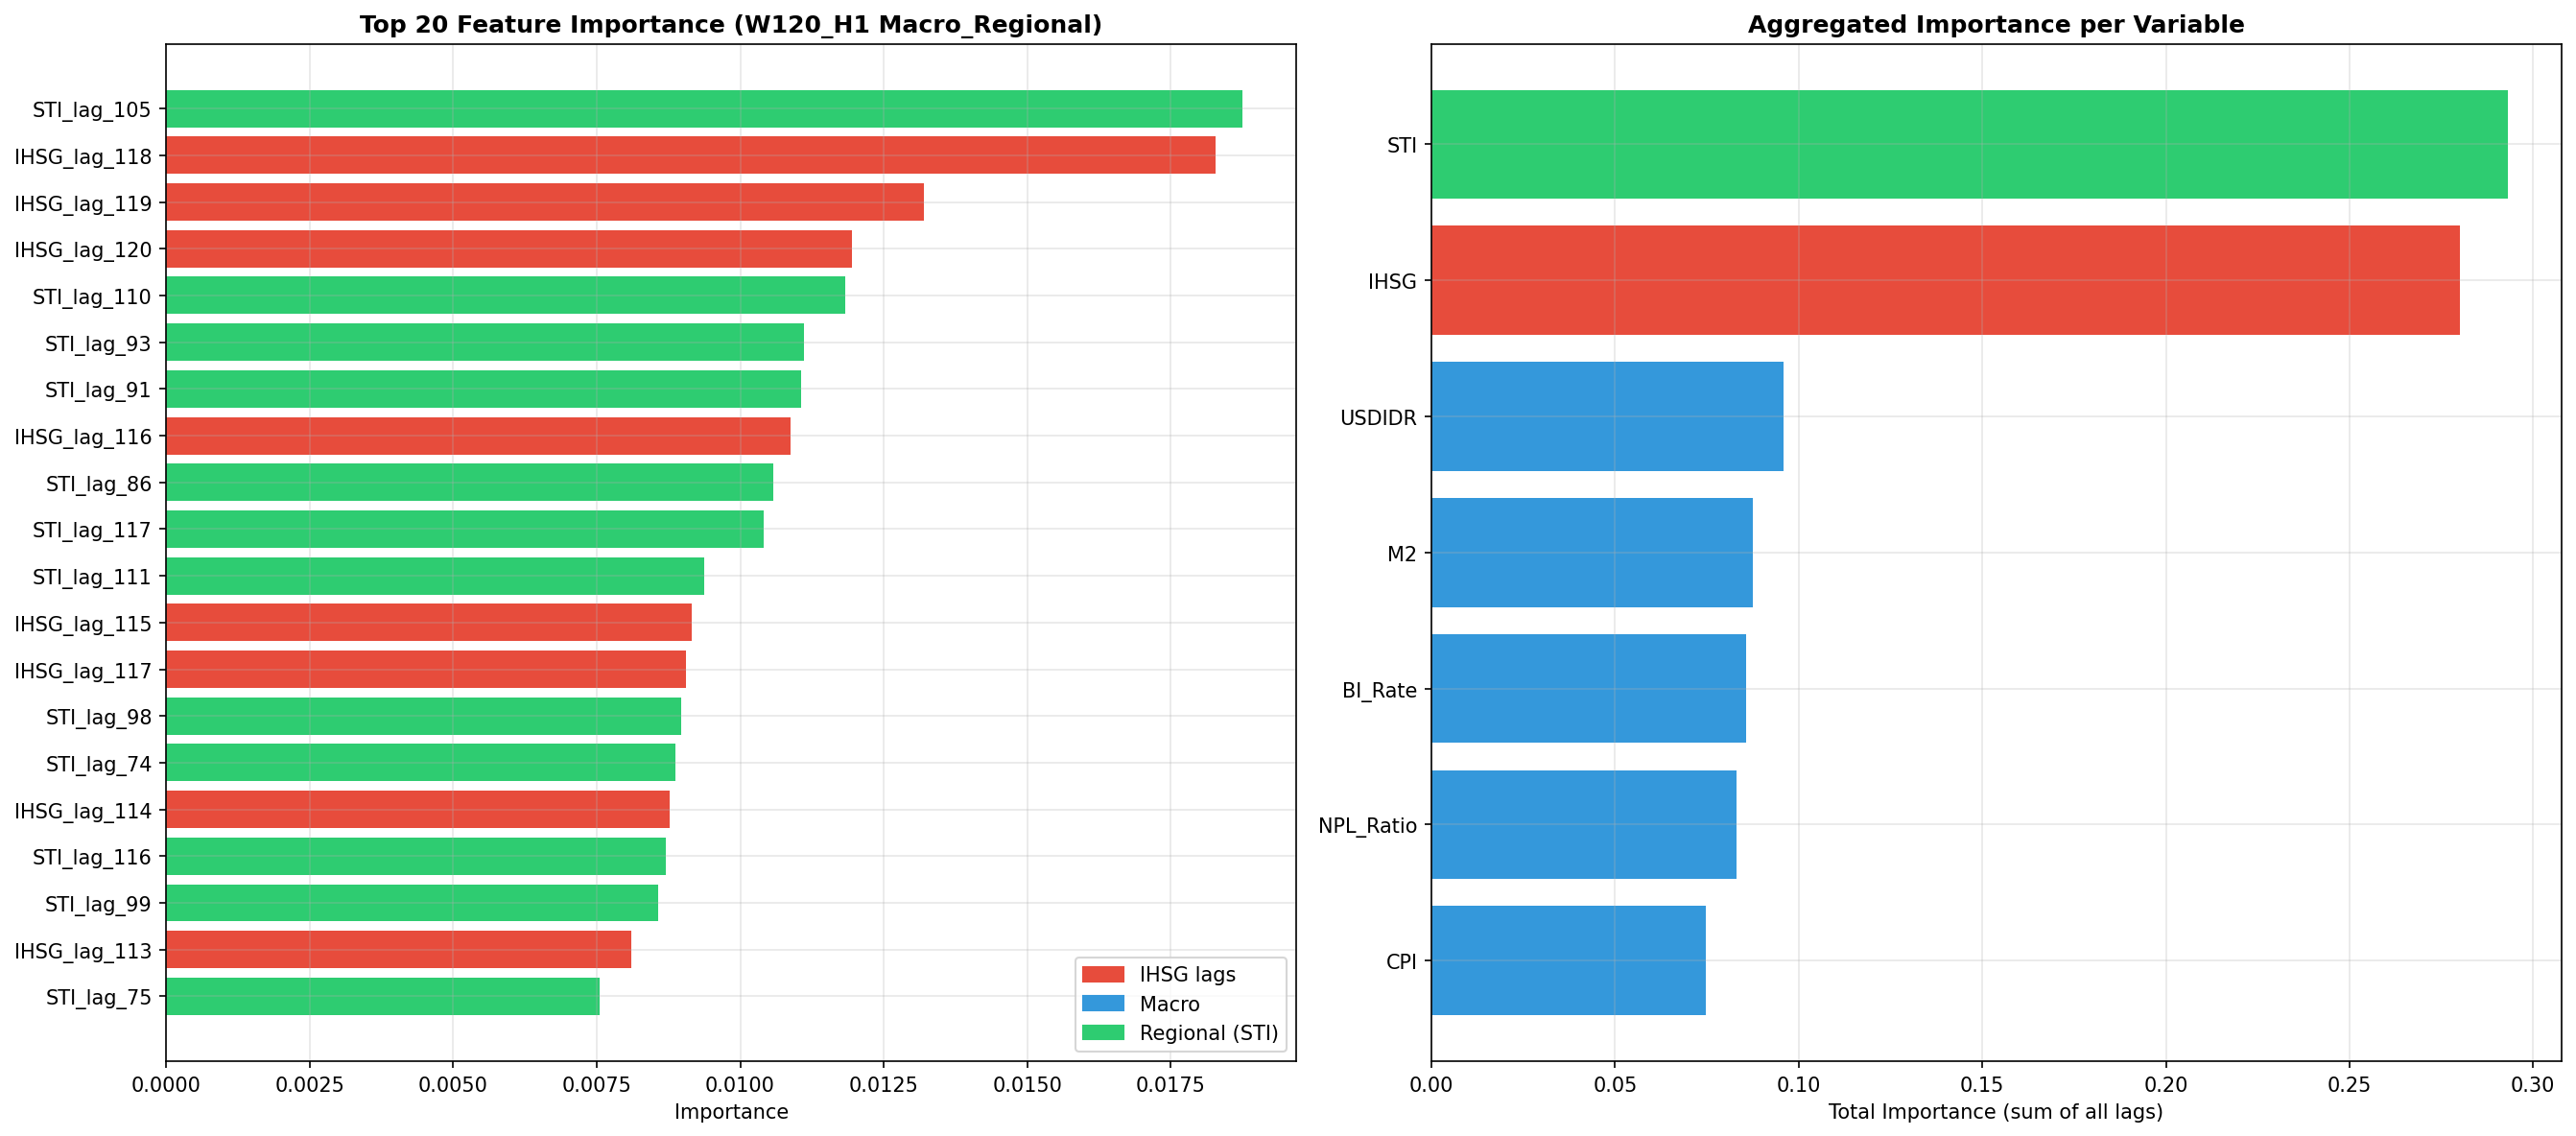


Aggregated importance:
variable
STI          0.293109
IHSG         0.280134
USDIDR       0.095948
M2           0.087496
BI_Rate      0.085573
NPL_Ratio    0.083096
CPI          0.074643


In [30]:
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# === Top 20 Feature Importance dari best config (W120_H1 Macro_Regional) ===
best_fi = predictions_final["W120_H1_Macro_Regional_fi"].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top 20 individual features
top20 = best_fi.head(20)
ax1 = axes[0]
colors = ["#e74c3c" if "IHSG" in f else "#3498db" if any(m in f for m in ["BI_Rate", "CPI", "M2", "USDIDR", "NPL_Ratio"]) else "#2ecc71" for f in top20["feature"]]
ax1.barh(range(len(top20)), top20["importance"].values, color=colors)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20["feature"].values)
ax1.invert_yaxis()
ax1.set_title("Top 20 Feature Importance (W120_H1 Macro_Regional)", fontweight="bold")
ax1.set_xlabel("Importance")
# Legend
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color="#e74c3c", label="IHSG lags"),
    Patch(color="#3498db", label="Macro"),
    Patch(color="#2ecc71", label="Regional (STI)"),
], loc="lower right")

# Plot 2: Aggregated importance per variable
best_fi["variable"] = best_fi["feature"].str.replace(r"_lag_\d+", "", regex=True)
fi_grouped = best_fi.groupby("variable")["importance"].sum().sort_values(ascending=True)

colors2 = []
for v in fi_grouped.index:
    if v == "IHSG":
        colors2.append("#e74c3c")
    elif v in ["BI_Rate", "CPI", "M2", "USDIDR", "NPL_Ratio"]:
        colors2.append("#3498db")
    else:
        colors2.append("#2ecc71")

ax2 = axes[1]
ax2.barh(range(len(fi_grouped)), fi_grouped.values, color=colors2)
ax2.set_yticks(range(len(fi_grouped)))
ax2.set_yticklabels(fi_grouped.index)
ax2.set_title("Aggregated Importance per Variable", fontweight="bold")
ax2.set_xlabel("Total Importance (sum of all lags)")

plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAggregated importance:")
print(fi_grouped.sort_values(ascending=False).to_string())


Visualization data ready: 394 test predictions


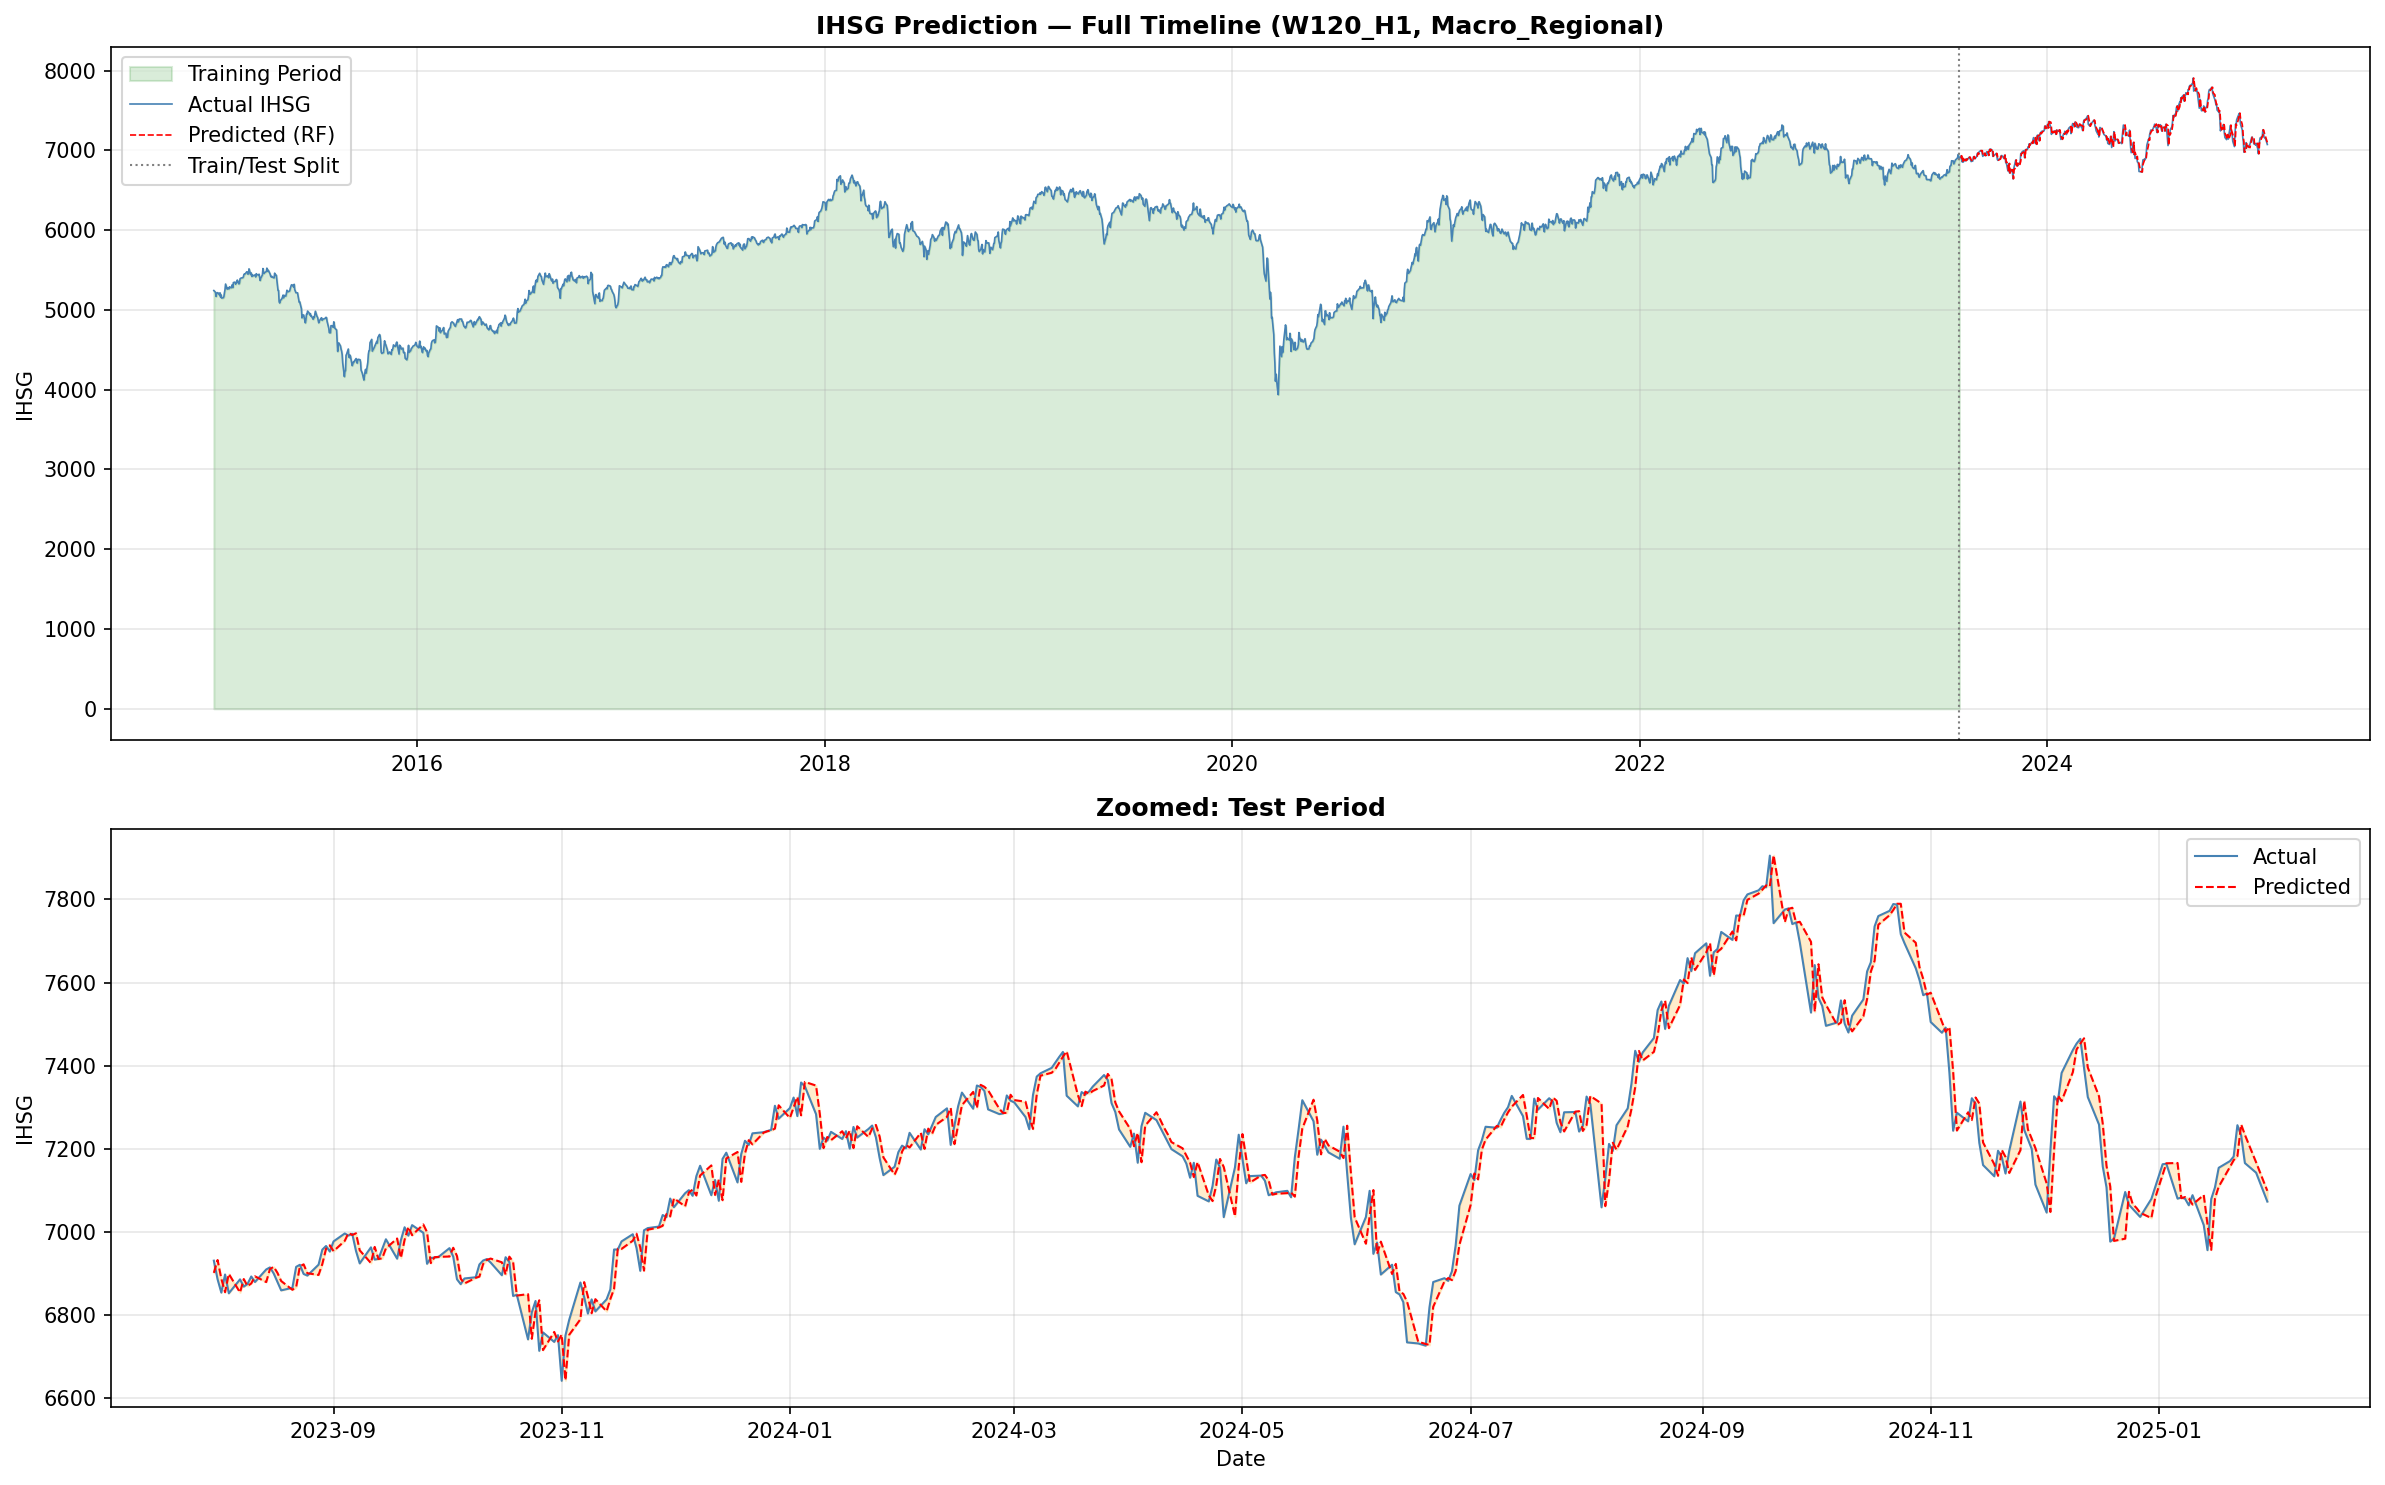

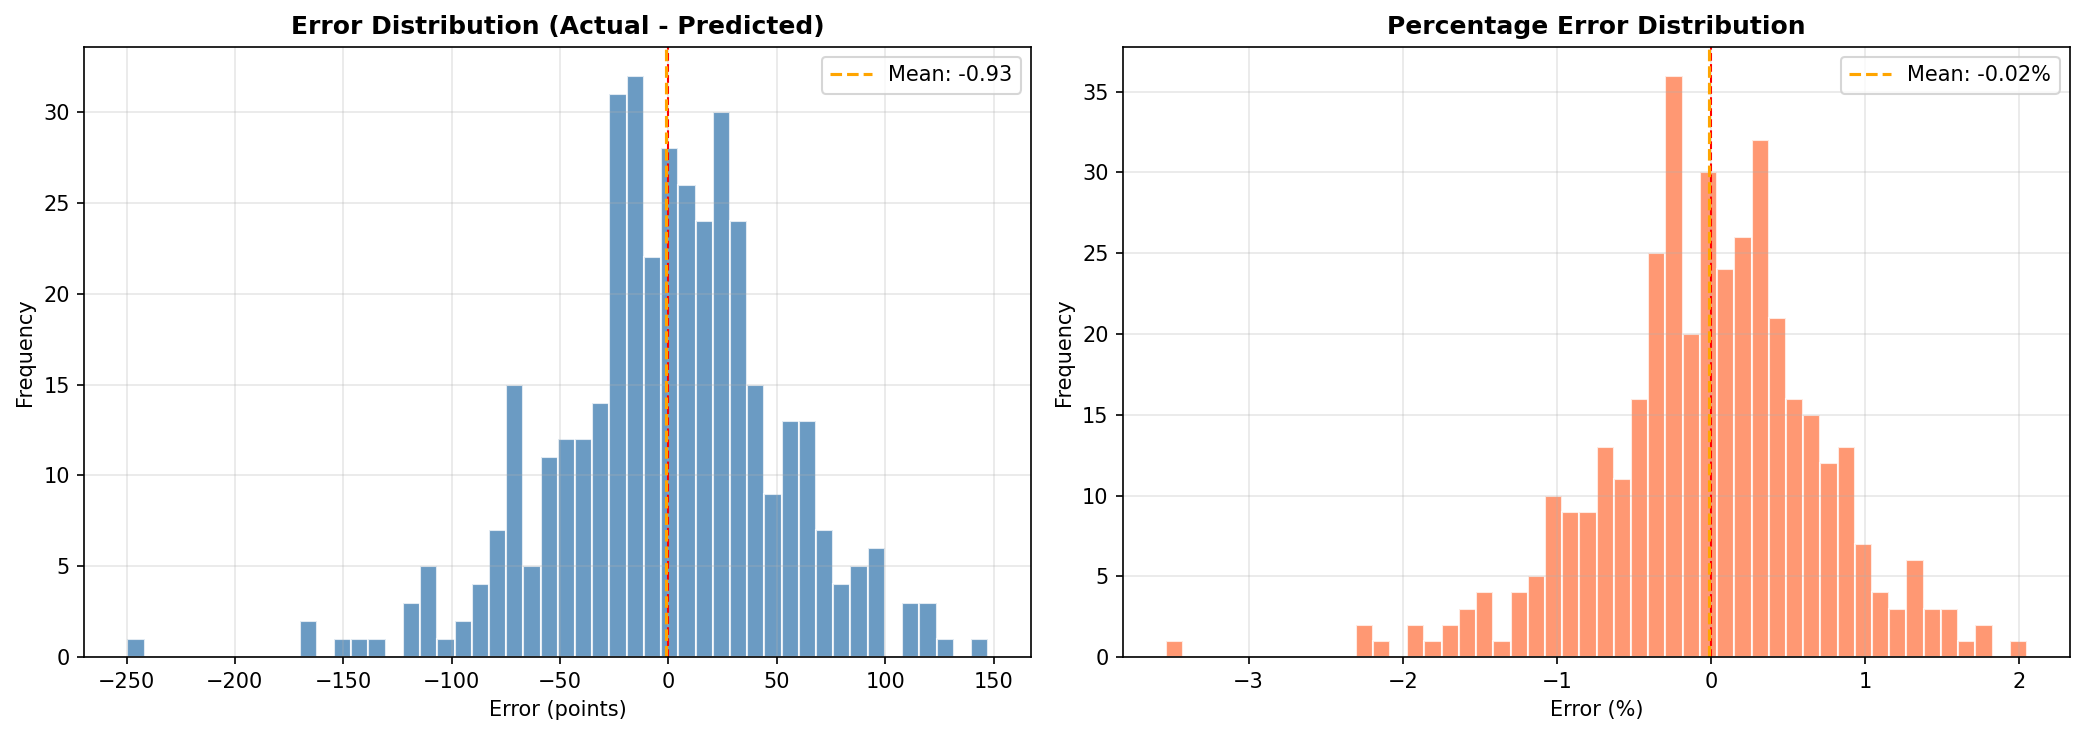

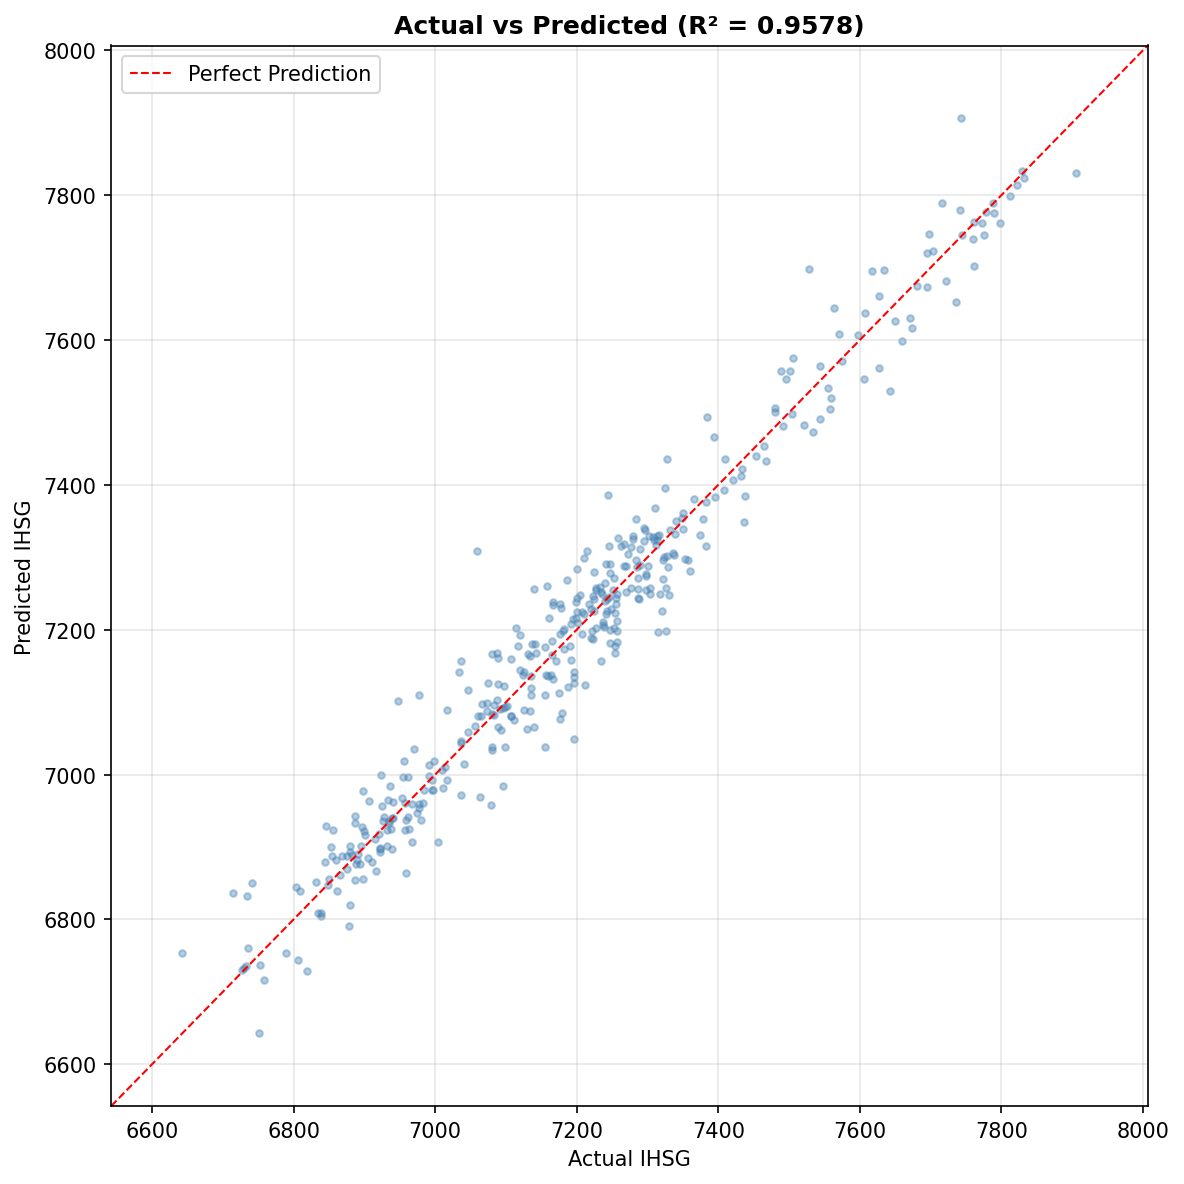

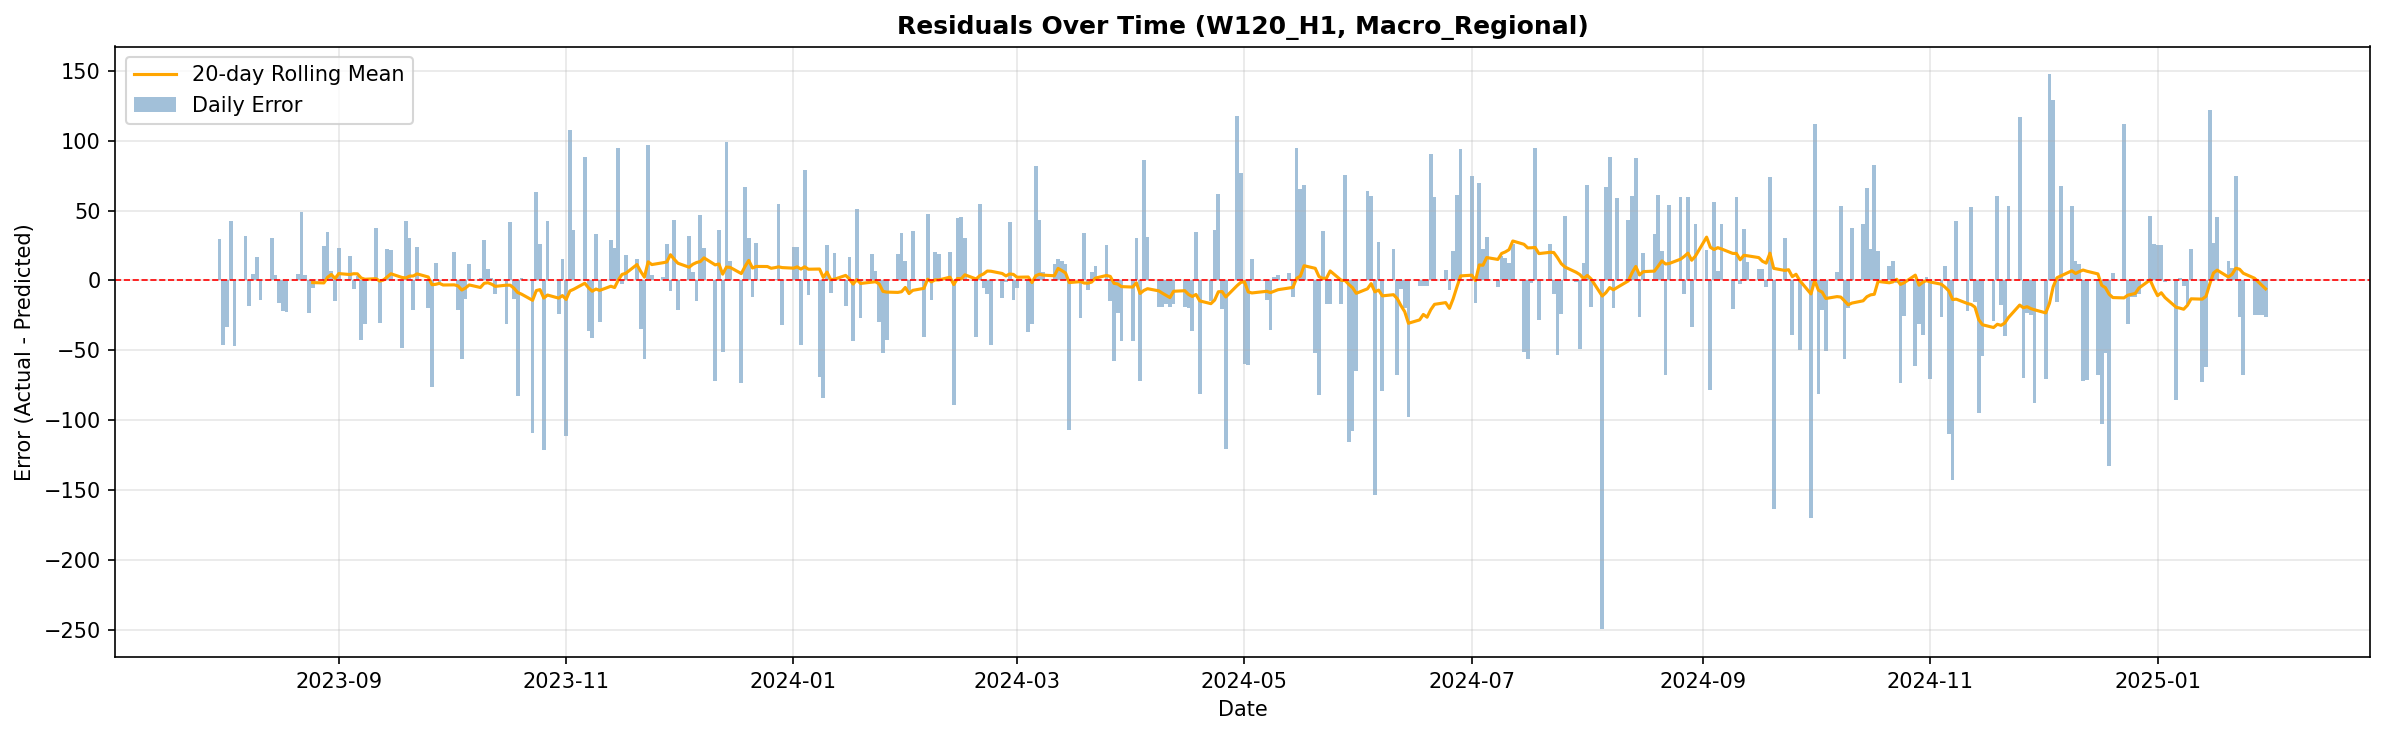

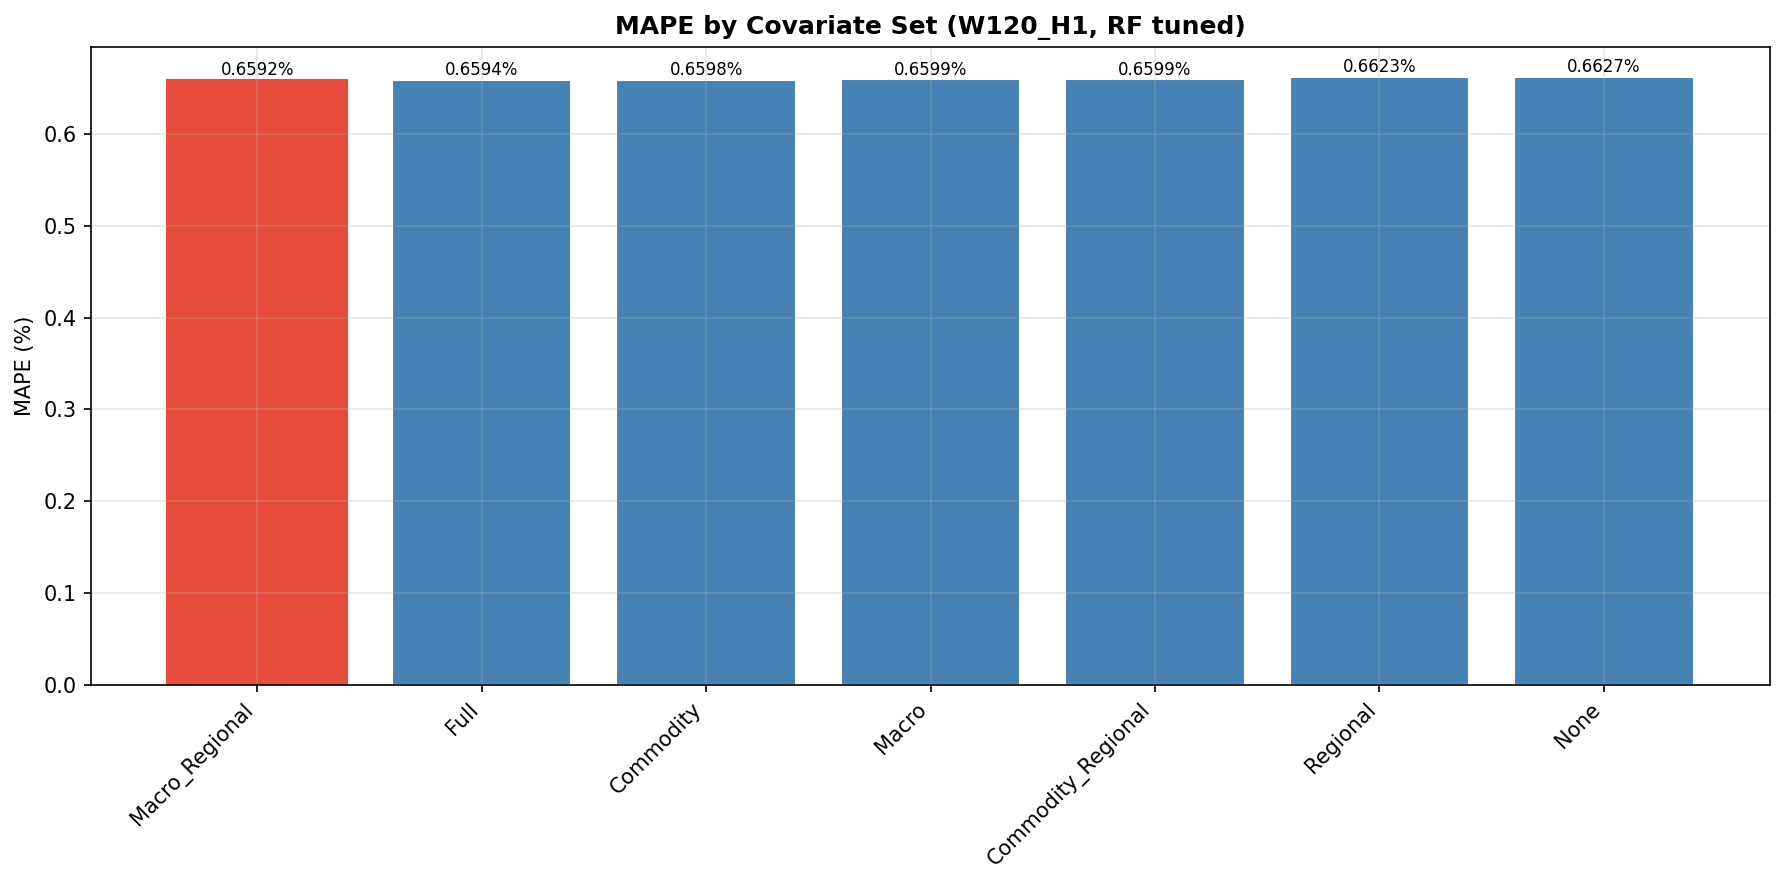

In [31]:
# === Re-run best config sekali untuk mendapatkan prediksi visualisasi ===
# Gunakan fold terakhir (paling mirip real-world scenario)

target_series, covariate_series = to_series(df_merged, "IHSG", COVARIATE_SETS["Macro_Regional"])

n = len(target_series)
test_size = int(n * 0.15)
min_train = int(n * 0.4)
available = n - min_train - test_size
step = max(1, available // 4)  # 5 folds

# Fold terakhir
train_end_idx = min_train + 4 * step
test_end_idx = min(train_end_idx + test_size, n)

train_ts = target_series[:train_end_idx]
fold_ts = target_series[:test_end_idx]

# Transform target
fold_log = fold_ts.map(np.log)
train_log = train_ts.map(np.log)
differencer = Diff(lags=1)
train_log_diff = differencer.fit_transform(train_log)
fold_log_diff = differencer.transform(fold_log)
scaler = Scaler()
train_scaled = scaler.fit_transform(train_log_diff)
fold_scaled = scaler.transform(fold_log_diff)

# Transform covariate
cov_fold = covariate_series[:test_end_idx]
cov_train = covariate_series[:train_end_idx]
cov_cols = covariate_series.components.tolist()
level_cols = [c for c in cov_cols if c in LEVEL_VARS]
rate_cols = [c for c in cov_cols if c in RATE_VARS]

parts_train = []
parts_fold = []
if level_cols:
    d1 = Diff(lags=1)
    parts_train.append(d1.fit_transform(cov_train[level_cols].map(np.log)))
    parts_fold.append(d1.transform(cov_fold[level_cols].map(np.log)))
if rate_cols:
    d2 = Diff(lags=1)
    parts_train.append(d2.fit_transform(cov_train[rate_cols]))
    parts_fold.append(d2.transform(cov_fold[rate_cols]))

cov_train_combined = parts_train[0]
cov_fold_combined = parts_fold[0]
for p_tr, p_fo in zip(parts_train[1:], parts_fold[1:]):
    cov_train_combined = cov_train_combined.stack(p_tr)
    cov_fold_combined = cov_fold_combined.stack(p_fo)

cov_scaler = Scaler()
cov_scaler.fit(cov_train_combined)
cov_transformed = cov_scaler.transform(cov_fold_combined)

# Train
model = RandomForestModel(lags=120, lags_past_covariates=120, output_chunk_length=1, **RF_CONFIG_FINAL)
model.fit(train_scaled, past_covariates=cov_transformed)

# Predict
test_ts = target_series[train_end_idx:test_end_idx]
forecast_list = model.historical_forecasts(
    series=fold_scaled, past_covariates=cov_transformed,
    start=test_ts.start_time(), forecast_horizon=1, stride=1,
    retrain=False, last_points_only=False, verbose=False
)
if isinstance(forecast_list, TimeSeries):
    forecast_list = [forecast_list]

all_pred_dates, all_pred_prices = [], []
fold_log_full = fold_ts.map(np.log)
for chunk in forecast_list:
    chunk_diff = scaler.inverse_transform(chunk)
    dates = chunk_diff.time_index
    vals = chunk_diff.values().flatten()
    idx = fold_ts.get_index_at_point(dates[0])
    anchor = fold_log_full[idx - 1].values()[0][0]
    prices = np.exp(anchor + np.cumsum(vals))
    all_pred_dates.extend(dates)
    all_pred_prices.extend(prices)

pred_df = pd.DataFrame({"date": pd.to_datetime(all_pred_dates), "predicted": all_pred_prices})
actual_df = fold_ts.to_dataframe().reset_index()
actual_df.columns = ["date", "actual"]
viz_df = pd.merge(actual_df, pred_df, on="date", how="left")
viz_df["train_flag"] = (viz_df["date"] <= train_ts.end_time()).astype(int)

test_pred = viz_df.dropna(subset=["predicted"])
print(f"Visualization data ready: {len(test_pred)} test predictions")

# === PLOT 1: Full Timeline + Zoomed Test ===
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1.2, 1]})

train_data = viz_df[viz_df["train_flag"] == 1]
test_data = viz_df[viz_df["train_flag"] == 0]

ax1 = axes[0]
ax1.fill_between(train_data["date"], 0, train_data["actual"], alpha=0.15, color="green", label="Training Period")
ax1.plot(viz_df["date"], viz_df["actual"], color="steelblue", linewidth=0.8, label="Actual IHSG")
ax1.plot(test_pred["date"], test_pred["predicted"], color="red", linewidth=0.8, linestyle="--", label="Predicted (RF)")
ax1.axvline(x=train_data["date"].max(), color="gray", linestyle=":", linewidth=1, label="Train/Test Split")
ax1.set_title("IHSG Prediction — Full Timeline (W120_H1, Macro_Regional)", fontweight="bold")
ax1.set_ylabel("IHSG")
ax1.legend(loc="upper left")

ax2 = axes[1]
ax2.plot(test_pred["date"], test_pred["actual"], color="steelblue", linewidth=1, label="Actual")
ax2.plot(test_pred["date"], test_pred["predicted"], color="red", linewidth=1, linestyle="--", label="Predicted")
ax2.fill_between(test_pred["date"], test_pred["actual"], test_pred["predicted"], alpha=0.2, color="orange")
ax2.set_title("Zoomed: Test Period", fontweight="bold")
ax2.set_ylabel("IHSG")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.savefig("plot_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# === PLOT 2: Error Distribution ===
errors = test_pred["actual"] - test_pred["predicted"]
pct_errors = (errors / test_pred["actual"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[0].axvline(x=errors.mean(), color="orange", linestyle="--", label=f"Mean: {errors.mean():.2f}")
axes[0].set_title("Error Distribution (Actual - Predicted)", fontweight="bold")
axes[0].set_xlabel("Error (points)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(pct_errors, bins=50, color="coral", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].axvline(x=pct_errors.mean(), color="orange", linestyle="--", label=f"Mean: {pct_errors.mean():.2f}%")
axes[1].set_title("Percentage Error Distribution", fontweight="bold")
axes[1].set_xlabel("Error (%)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# === PLOT 3: Scatter Actual vs Predicted ===
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test_pred["actual"], test_pred["predicted"], alpha=0.4, s=10, color="steelblue")
min_val = min(test_pred["actual"].min(), test_pred["predicted"].min()) - 100
max_val = max(test_pred["actual"].max(), test_pred["predicted"].max()) + 100
ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1, label="Perfect Prediction")

ss_res = np.sum((test_pred["actual"] - test_pred["predicted"]) ** 2)
ss_tot = np.sum((test_pred["actual"] - test_pred["actual"].mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

ax.set_title(f"Actual vs Predicted (R² = {r2:.4f})", fontweight="bold")
ax.set_xlabel("Actual IHSG")
ax.set_ylabel("Predicted IHSG")
ax.legend()
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

plt.tight_layout()
plt.savefig("plot_scatter_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# === PLOT 4: Residuals Over Time ===
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(test_pred["date"], errors.values, width=1, alpha=0.5, color="steelblue", label="Daily Error")
rolling_mean = errors.rolling(20).mean()
ax.plot(test_pred["date"], rolling_mean.values, color="orange", linewidth=1.5, label="20-day Rolling Mean")
ax.axhline(y=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Residuals Over Time (W120_H1, Macro_Regional)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Error (Actual - Predicted)")
ax.legend()

plt.tight_layout()
plt.savefig("plot_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

# === PLOT 5: Covariate Comparison Bar Chart ===
comparison = results_final_df[results_final_df["Scenario"] == "W120_H1"].sort_values("MAPE")

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(comparison))
bars = ax.bar(x, comparison["MAPE"].values, color="steelblue", edgecolor="white")

# Highlight best
bars[0].set_color("#e74c3c")

ax.set_xticks(x)
ax.set_xticklabels(comparison["Covariates"].values, rotation=45, ha="right")
ax.set_title("MAPE by Covariate Set (W120_H1, RF tuned)", fontweight="bold")
ax.set_ylabel("MAPE (%)")

# Add value labels
for i, (bar, val) in enumerate(zip(bars, comparison["MAPE"].values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.4f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("plot_covariate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# 1. Main results
results_final_df.to_csv(f"rf_final_results_{timestamp}.csv", index=False)
print(f"Saved: rf_final_results_{timestamp}.csv")

# 2. Feature importance (best config)
best_fi_save = predictions_final["W120_H1_Macro_Regional_fi"]
best_fi_save.to_csv(f"rf_feature_importance_{timestamp}.csv", index=False)
print(f"Saved: rf_feature_importance_{timestamp}.csv")

# 3. Predictions (for reproducibility)
test_pred.to_csv(f"rf_predictions_best_{timestamp}.csv", index=False)
print(f"Saved: rf_predictions_best_{timestamp}.csv")

# 4. Summary print
print("\n" + "=" * 75)
print("FINAL RESULTS SUMMARY — RANDOM FOREST (Tuned)")
print("=" * 75)
print(f"Best Config     : W120_H1 + Macro_Regional")
print(f"Hyperparameters : n_est=500, max_depth=5, max_feat=sqrt")
print(f"Validation      : 5-Fold Expanding Window CV")
print(f"Date Range      : {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")
print(f"\n{'Scenario':<10} | {'Covariates':<20} | {'MAPE':>12} | {'RMSE':>12} | {'R2':>10} | {'DA':>10}")
print("-" * 85)
for _, row in results_final_df.sort_values("MAPE").iterrows():
    print(f"{row['Scenario']:<10} | {row['Covariates']:<20} | {row['MAPE']:.4f}±{row['MAPE_std']:.4f} | {row['RMSE']:.2f}±{row['RMSE_std']:.2f} | {row['R2']:.4f}±{row['R2_std']:.4f} | {row['DA']:.1f}±{row['DA_std']:.1f}")


Saved: rf_final_results_20260326_1652.csv
Saved: rf_feature_importance_20260326_1652.csv
Saved: rf_predictions_best_20260326_1652.csv

FINAL RESULTS SUMMARY — RANDOM FOREST (Tuned)
Best Config     : W120_H1 + Macro_Regional
Hyperparameters : n_est=500, max_depth=5, max_feat=sqrt
Validation      : 5-Fold Expanding Window CV
Date Range      : 2015-01-02 to 2025-01-31

Scenario   | Covariates           |         MAPE |         RMSE |         R2 |         DA
-------------------------------------------------------------------------------------
W120_H1    | Macro_Regional       | 0.6592±0.1822 | 55.22±10.54 | 0.9690±0.0303 | 53.2±2.1
W30_H1     | Commodity            | 0.6594±0.1834 | 55.05±10.56 | 0.9693±0.0297 | 53.2±1.9
W120_H1    | Full                 | 0.6594±0.1823 | 55.14±10.38 | 0.9689±0.0306 | 51.7±1.8
W30_H1     | Full                 | 0.6597±0.1830 | 55.17±10.60 | 0.9691±0.0300 | 53.4±1.9
W60_H1     | Commodity_Regional   | 0.6598±0.1830 | 55.18±10.60 | 0.9692±0.0300 | 52.1±2.2


## save model

In [33]:
import joblib
import os

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# 1. Save semua hasil eksperimen
joblib.dump({
    "results_final_df": results_final_df,
    "predictions_final": predictions_final,
    "RF_CONFIG_FINAL": RF_CONFIG_FINAL,
    "SCENARIOS": SCENARIOS,
    "COVARIATE_SETS": COVARIATE_SETS,
}, f"{save_dir}/experiment_results_{timestamp}.joblib")

# 2. Save data merged (supaya tidak perlu download ulang)
joblib.dump(df_merged, f"{save_dir}/df_merged_{timestamp}.joblib")

print(f"Saved to {save_dir}/")
print(f"  experiment_results_{timestamp}.joblib")
print(f"  df_merged_{timestamp}.joblib")


Saved to saved_models/
  experiment_results_20260326_1654.joblib
  df_merged_20260326_1654.joblib


## load model

In [ ]:
import joblib

# Ganti dengan timestamp yang sesuai
ts = "20260326_1700"  # ← sesuaikan

df_merged = joblib.load(f"saved_models/df_merged_{ts}.joblib")

exp = joblib.load(f"saved_models/experiment_results_{ts}.joblib")
results_final_df = exp["results_final_df"]
predictions_final = exp["predictions_final"]
RF_CONFIG_FINAL = exp["RF_CONFIG_FINAL"]
SCENARIOS = exp["SCENARIOS"]
COVARIATE_SETS = exp["COVARIATE_SETS"]

print("Loaded successfully!")
print(f"Results: {len(results_final_df)} experiments")
display(results_final_df.sort_values("MAPE"))
